<a href="https://colab.research.google.com/github/vappanna/BerAIML/blob/main/PartsProjection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- STEP 1: UPLOAD 3 FILES ---


Saving FINAL_2027_ITEM_PROJECTION.csv to FINAL_2027_ITEM_PROJECTION (2).csv
Saving Aggregated_Item_Data_Fuzzy.csv to Aggregated_Item_Data_Fuzzy (2).csv
Saving processed_usage.csv to processed_usage (2).csv
--- STEP 2: CALCULATING RATES ---
--- STEP 3: PROCESSING BY REGION (RAM-SAFE) ---
  > Processing: Canada
  > Processing: China
  > Processing: France
  > Processing: Germany
  > Processing: India
  > Processing: Italy
  > Processing: Japan
  > Processing: South Korea
  > Processing: Taiwan
  > Processing: United Kingdom
  > Processing: United States
--- STEP 4: GENERATING VISUALIZATIONS ---

--- ✅ COMPLETED ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

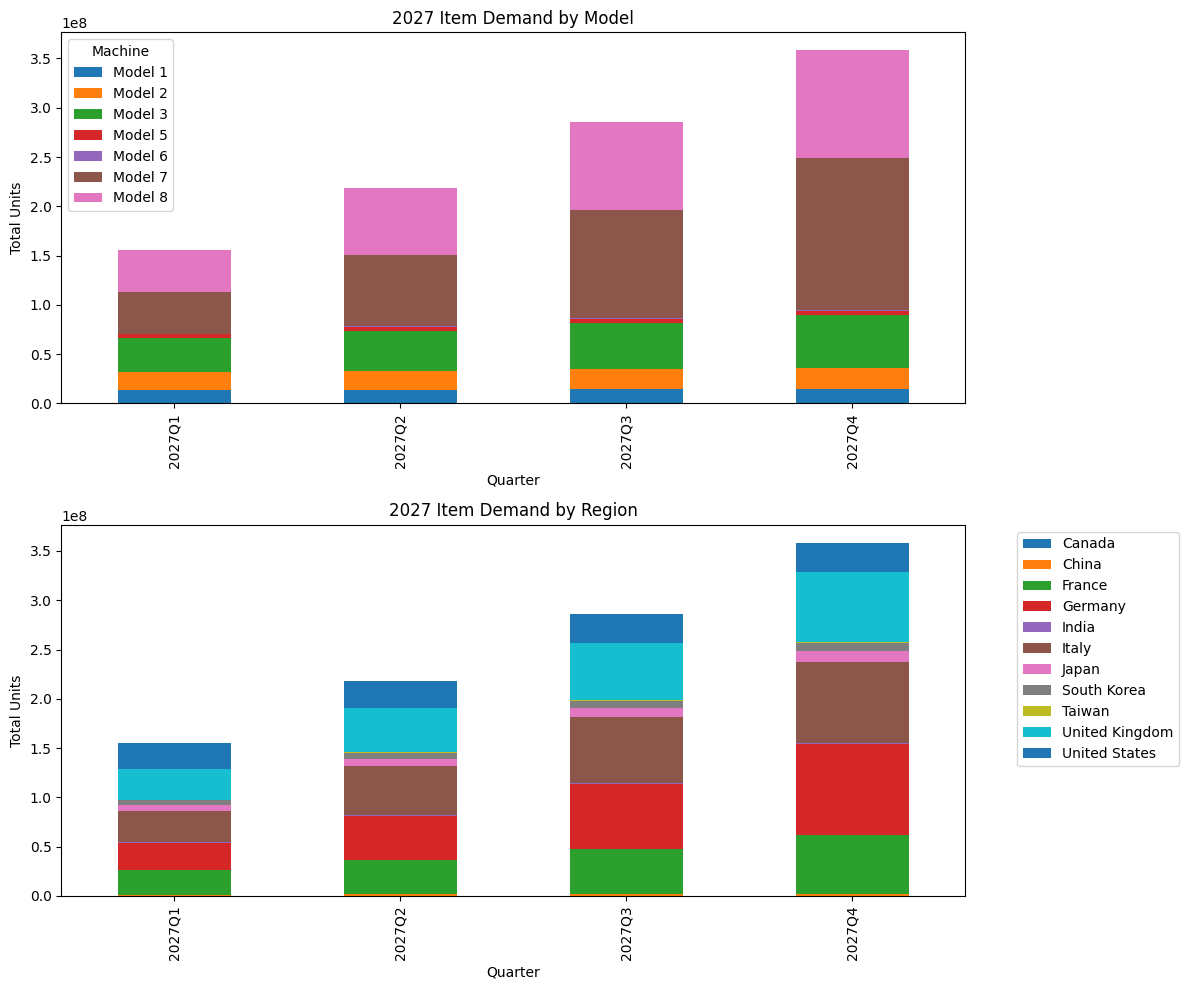

In [2]:
import pandas as pd
import numpy as np
import io
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

def safe_load(uploaded_dict, keyword):
    """Memory-efficient loader with encoding fallback."""
    fname = next((k for k in uploaded_dict.keys() if keyword.lower() in k.lower()), None)
    if not fname: return None
    content = uploaded_dict[fname]
    for enc in ['utf-8', 'latin1', 'cp1252']:
        try:
            df = pd.read_csv(io.BytesIO(content), encoding=enc)
            df.columns = [str(c).strip() for c in df.columns]
            return df
        except: continue
    return None

def run_chunked_projection():
    print("--- STEP 1: UPLOAD 3 FILES ---")
    uploaded = files.upload()

    # 1. Load Data
    df_proj = safe_load(uploaded, 'FINAL_2027')
    df_item_hist = safe_load(uploaded, 'Aggregated_Item_Data')
    df_usage_hist = safe_load(uploaded, 'processed_usage')

    if any(df is None for df in [df_proj, df_item_hist, df_usage_hist]):
        print("❌ Error: Missing files.")
        return

    # 2. Regional Mapping
    region_to_macro = {
        'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
        'France': 'Europe', 'Germany': 'Europe', 'Italy': 'Europe', 'United Kingdom': 'Europe',
        'United States': 'US', 'Canada': 'US',
        'Asia : China': 'Asia', 'Asia : India': 'Asia', 'Asia : Japan': 'Asia',
        'Asia : Korea': 'Asia', 'Asia : Taiwan': 'Asia',
        'EU : DACH': 'Europe', 'EU : France': 'Europe', 'EU : Italy': 'Europe', 'EU : UK & Ireland': 'Europe',
        'US : West': 'US', 'US : East': 'US', 'US : South Central': 'US', 'US : North Central': 'US',
        'US : Mid-Atlantic': 'US', 'US : Mountain': 'US', 'US : Northeast': 'US',
        'US : Ohio Valley': 'US', 'US : Pacific Mountain': 'US', 'US : Southeast': 'US'
    }

    print("--- STEP 2: CALCULATING RATES ---")
    # Mapping
    df_usage_hist['Macro_Region'] = df_usage_hist['REGION'].map(region_to_macro).fillna('Other')
    df_proj['Macro_Region'] = df_proj['Region'].map(region_to_macro).fillna('Other')

    # Calculate Rates
    hist_usage_grp = df_usage_hist.groupby(['Macro_Region', 'Machine'])['Usage'].sum().reset_index()
    item_usage_grp = df_item_hist.groupby(['Region', 'Model', 'Item'])['Total_Quantity'].sum().reset_index()

    rates = pd.merge(item_usage_grp, hist_usage_grp,
                     left_on=['Region', 'Model'],
                     right_on=['Macro_Region', 'Machine'], how='inner')
    rates['Rate'] = rates['Total_Quantity'] / rates['Usage']
    rates = rates[['Macro_Region', 'Machine', 'Item', 'Rate']]
    rates = rates[rates['Rate'] > 0]

    # Free up memory from old dataframes
    del df_item_hist
    del df_usage_hist
    del hist_usage_grp
    del item_usage_grp

    print("--- STEP 3: PROCESSING BY REGION (RAM-SAFE) ---")
    output_file = "FINAL_2027_ITEM_FORECAST.csv"
    if os.path.exists(output_file): os.remove(output_file)

    summary_list = [] # For plotting later

    # Process each region one by one to save RAM
    all_regions = df_proj['Region'].unique()
    for reg in all_regions:
        print(f"  > Processing: {reg}")
        chunk = df_proj[df_proj['Region'] == reg]

        # Merge with rates for this specific chunk
        forecast_chunk = pd.merge(chunk, rates, on=['Macro_Region', 'Machine'], how='inner')
        forecast_chunk['Projected_Demand'] = (forecast_chunk['Projected_Usage_Units'] * forecast_chunk['Rate']).round(0)

        # Capture summary for plotting
        summary_list.append(forecast_chunk.groupby(['Quarter', 'Region', 'Machine'])['Projected_Demand'].sum().reset_index())

        # Write to disk
        forecast_chunk.to_csv(output_file, mode='a', index=False, header=not os.path.exists(output_file))
        del forecast_chunk

    print("--- STEP 4: GENERATING VISUALIZATIONS ---")
    df_summary = pd.concat(summary_list)

    plt.figure(figsize=(12, 10))

    # Plot by Model
    plt.subplot(2, 1, 1)
    df_summary.groupby(['Quarter', 'Machine'])['Projected_Demand'].sum().unstack().plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title('2027 Item Demand by Model')
    plt.ylabel('Total Units')

    # Plot by Region
    plt.subplot(2, 1, 2)
    df_summary.groupby(['Quarter', 'Region'])['Projected_Demand'].sum().unstack().plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title('2027 Item Demand by Region')
    plt.ylabel('Total Units')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig("2027_Demand_Summary.png")

    print("\n--- ✅ COMPLETED ---")
    files.download(output_file)
    files.download("2027_Demand_Summary.png")

run_chunked_projection()